# Boundary Issues in Marginal Uniformization

This notebook examines what happens when test-time data points fall **outside**
the support seen during training (i.e. outside the empirical CDF bounds), and
how the new `rbig` API handles these boundary conditions.

The key class is `MarginalKDEGaussianize`, which uses a KDE-estimated CDF and
clips output probabilities to `[eps, 1-eps]` to avoid infinite values at the
boundaries.

For the underlying theory of the uniformization step, see the [Uniformization note](../notes/uniformization.md).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

from rbig import MarginalGaussianize, MarginalKDEGaussianize, MarginalUniformize

plt.style.use("seaborn-v0_8-paper")

/home/azureuser/localfiles/rbig/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_dist(x, bins=100, title="Distribution", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
    sns.histplot(
        x.ravel(),
        bins=bins,
        ax=ax,
        kde=True,
        line_kws={"linewidth": 2, "color": "black"},
        color="steelblue",
        alpha=0.6,
    )
    ax.set_title(title)
    return fig, ax

## Data

We draw samples from a Gamma distribution.

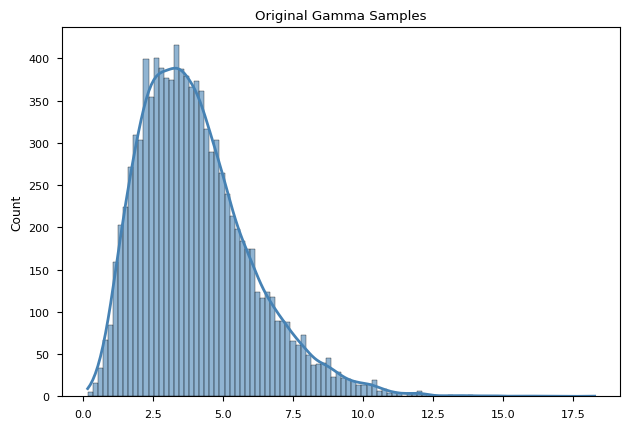

In [3]:
seed = 123
n_samples = 10_000
a = 4

data_dist = stats.gamma(a=a)
X = data_dist.rvs(size=(n_samples, 1), random_state=seed)

fig, ax = plt.subplots()
plot_dist(X, bins=100, title="Original Gamma Samples", ax=ax)
plt.tight_layout()
plt.show()

## CDF Estimation via Quantiles

Before looking at the new API, we manually inspect the empirical CDF to
understand where boundary issues arise.

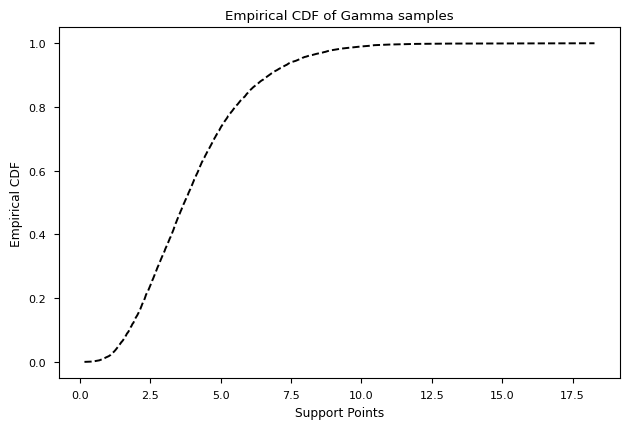

In [4]:
n_quantiles = 1_000
n_quantiles = max(1, min(n_quantiles, n_samples))

# Reference values (uniform grid over [0, 1])
references = np.linspace(0, 1, n_quantiles, endpoint=True)

# Empirical quantiles
quantiles = np.percentile(X.ravel(), references * 100)

fig, ax = plt.subplots()
ax.plot(quantiles, references, linestyle="--", color="black")
ax.set_xlabel("Support Points")
ax.set_ylabel("Empirical CDF")
ax.set_title("Empirical CDF of Gamma samples")
plt.tight_layout()
plt.show()

## Boundary Problem

If test-time samples fall outside the support of the training data, the CDF
returns 0 or 1, and the probit (Φ⁻¹) diverges to ±∞.

In [5]:
print(f"Training data range : [{X.min():.3f}, {X.max():.3f}]")
print(f"Quantile range      : [{quantiles.min():.3f}, {quantiles.max():.3f}]")

# Out-of-support test point
X_oos = np.array([[X.max() + 5.0]])
print(f"\nOut-of-support point: {X_oos[0, 0]:.3f}")

Training data range : [0.169, 18.275]
Quantile range      : [0.169, 18.275]

Out-of-support point: 23.275


### Method I — Empirical CDF Extension (`MarginalUniformize`)

`MarginalUniformize` uses `bound_correct=True` with a small `eps` to clip the
uniform output to `[eps, 1-eps]`, preventing downstream probit overflow.

In [6]:
marg_unif = MarginalUniformize(bound_correct=True, eps=1e-6)
marg_unif.fit(X)

# In-support sample
u_in = marg_unif.transform(X[:5])
print(f"In-support uniform values: {u_in[:, 0]}")

# Out-of-support sample — clipped to [eps, 1-eps]
u_oos = marg_unif.transform(X_oos)
print(f"Out-of-support uniform value (clipped): {u_oos[0, 0]:.8f}")

In-support uniform values: [0.13325 0.84035 0.27515 0.95055 0.00505]
Out-of-support uniform value (clipped): 0.99999900


### Method II — KDE CDF (`MarginalKDEGaussianize`)

`MarginalKDEGaussianize` smooths the CDF via KDE so the density extends
smoothly beyond the training data range.  Out-of-support points still get a
valid (non-zero) probability estimate from the KDE tails.

In [7]:
marg_kde = MarginalKDEGaussianize(bw_method="scott", eps=1e-6)
marg_kde.fit(X)

# In-support transform
Xg_in = marg_kde.transform(X[:10])
print(f"KDE Gaussianize (in-support, first 5): {Xg_in[:5, 0]}")

# Out-of-support transform — the KDE tail assigns a small (but finite) probability
Xg_oos = marg_kde.transform(X_oos)
print(f"KDE Gaussianize (out-of-support, +5 beyond max): {Xg_oos[0, 0]:.4f}")

KDE Gaussianize (in-support, first 5): [-1.09547703  0.9883879  -0.59745803  1.64444702 -2.34524146]
KDE Gaussianize (out-of-support, +5 beyond max): 4.7534


## Visual Comparison

Compare the transformed values from each method on the training data.

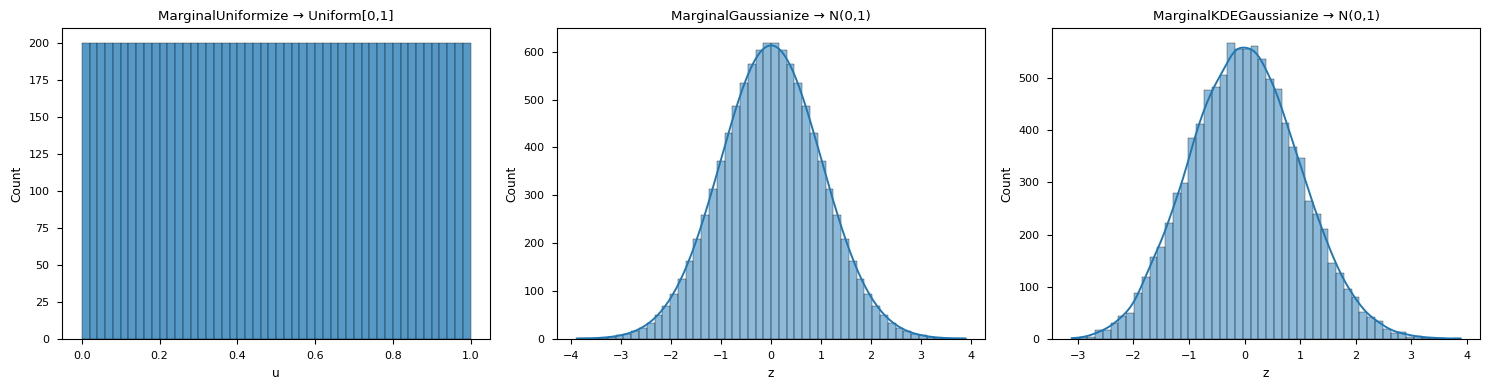

In [8]:
Xu_unif = marg_unif.transform(X)  # → Uniform
Xg_kde = marg_kde.transform(X)  # → Gaussian (KDE)

marg_emp = MarginalGaussianize()
marg_emp.fit(X)
Xg_emp = marg_emp.transform(X)  # → Gaussian (empirical CDF + probit)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].set_title("MarginalUniformize → Uniform[0,1]")
sns.histplot(Xu_unif[:, 0], ax=axes[0], bins=50)
axes[0].set_xlabel("u")

axes[1].set_title("MarginalGaussianize → N(0,1)")
sns.histplot(Xg_emp[:, 0], ax=axes[1], bins=50, kde=True)
axes[1].set_xlabel("z")

axes[2].set_title("MarginalKDEGaussianize → N(0,1)")
sns.histplot(Xg_kde[:, 0], ax=axes[2], bins=50, kde=True)
axes[2].set_xlabel("z")

plt.tight_layout()
plt.show()

## Quantile Boundary Extension — Manual Illustration

The following code reproduces the manual support-extension approach from the
original demo to illustrate the concept behind `MarginalUniformize`'s
`bound_correct` flag.

In [9]:
support_extension = 10  # percentage of domain to add on each side

domain = np.abs(quantiles.max() - quantiles.min())
domain_ext = (support_extension / 100) * domain

lower_bound = quantiles.min() - domain_ext
upper_bound = quantiles.max() + domain_ext

print(f"Original bounds : [{quantiles.min():.3f}, {quantiles.max():.3f}]")
print(f"Extended bounds : [{lower_bound:.3f}, {upper_bound:.3f}]")

Original bounds : [0.169, 18.275]
Extended bounds : [-1.642, 20.086]


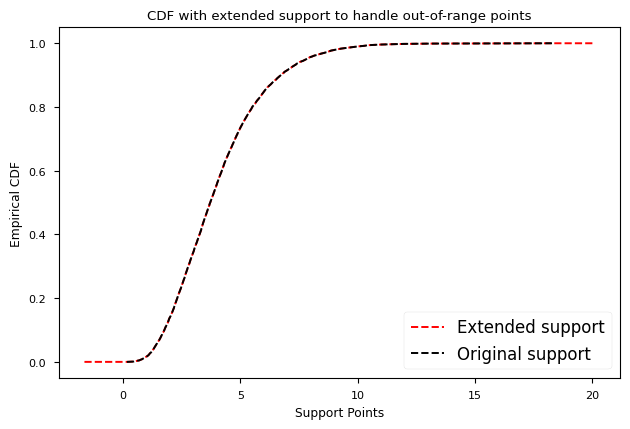

In [10]:
new_quantiles = np.hstack([lower_bound, quantiles, upper_bound])
new_references = np.interp(new_quantiles, quantiles, references)

fig, ax = plt.subplots()
ax.plot(
    new_quantiles, new_references, linestyle="--", color="red", label="Extended support"
)
ax.plot(quantiles, references, linestyle="--", color="black", label="Original support")
ax.legend(fontsize=12)
ax.set_xlabel("Support Points")
ax.set_ylabel("Empirical CDF")
ax.set_title("CDF with extended support to handle out-of-range points")
plt.tight_layout()
plt.show()

## Summary

| Class | Boundary handling | Output distribution |
|---|---|---|
| `MarginalUniformize(bound_correct=True, eps=ε)` | Clips uniform output to `[ε, 1-ε]` | Uniform[0,1] |
| `MarginalGaussianize(bound_correct=True, eps=ε)` | Clips before probit | Standard Gaussian |
| `MarginalKDEGaussianize(eps=ε)` | KDE tails extend beyond training range | Standard Gaussian |

In all cases, the `eps` parameter prevents the probit from diverging and
ensures numerically stable downstream computations.

---
## See Also

- [Uniformization Note](../notes/uniformization.md) — theory of the CDF-based uniformization step
- [Marginal Gaussianization Note](../notes/marginal_gaussianization.md) — marginal Gaussianization theory
- [Marginal Transforms](./01_marginal_transforms.ipynb) — hands-on demo of marginal transform classes